# Human Reference: Version 2 vs Version 3

We compare the two human references; v2 and v3; by mapping two ribosome profiling experiments to these references. We used the experiments
[GSM1606107](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM1606107) and
[GSM1606108](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM1606108).
We processed them using the same parameters in RiboFlow.
The overall ribosome profiling QC metrics are almost the same.

The only notable differences exist in the CDS occupancy of a small number of genes.
Generally, this is because APPRIS picked a different principal isoform between v2 and v3, which redistributes reads across homologs.

In [1]:
import matplotlib
import matplotlib.pyplot  as plt

import ribopy
from ribopy import Ribo

import numpy as np
import pandas as pd

%matplotlib inline

import IPython

# Some formatting forthe rest of the notebook
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

## Ribo Files

In [2]:
ribo_2_path = "/Users/danielnguyen/Cenik/CCLE/Transcriptome/grace_ultima/references_for_riboflow/v2.ribo"
ribo_2      = Ribo(ribo_2_path, alias = ribopy.api.alias.apris_human_alias)

ribo_3_path = "/Users/danielnguyen/Cenik/CCLE/Transcriptome/grace_ultima/references_for_riboflow/v3.ribo"
ribo_3      = Ribo(ribo_3_path, alias = ribopy.api.alias.apris_human_alias)

In [3]:
ribo_2.print_info()

Ribo File Info:
---------------
Ribo File Version : 1.0
RiboPy Version    : 0.0.1
Creation Time     : 2026-05-20 17:20:03
Reference         : appris-v3
Min Read Length   : 28
Max Read Length   : 32
Metagene Radius   : 50
Left Span         : 35
Right Span        : 10

Experiments:
------------ 
Name          Reads  Coverage  RNA-Seq  Metadata
GSM1606107  3971928         *                   
GSM1606108  5896151         *                   


In [4]:
ribo_3.print_info()

Ribo File Info:
---------------
Ribo File Version : 1.0
RiboPy Version    : 0.0.1
Creation Time     : 2026-05-20 12:22:11
Reference         : appris-v3
Min Read Length   : 28
Max Read Length   : 32
Metagene Radius   : 50
Left Span         : 35
Right Span        : 10

Experiments:
------------ 
Name          Reads  Coverage  RNA-Seq  Metadata
GSM1606107  3956452         *                   
GSM1606108  5874351         *                   


## Length Distribution

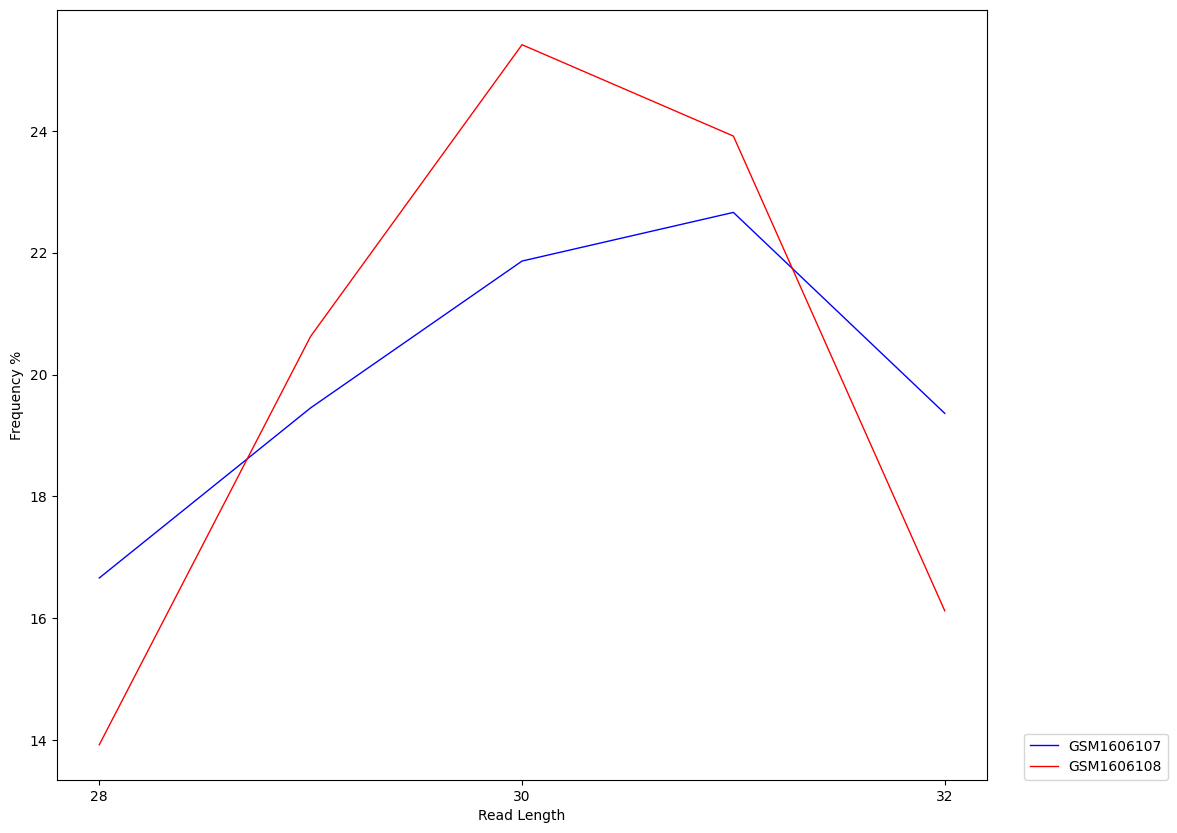

In [5]:
ribo_2.plot_lengthdist(region_type      = "CDS",
                            normalize   = True,
                            experiments = ["GSM1606107", "GSM1606108"])

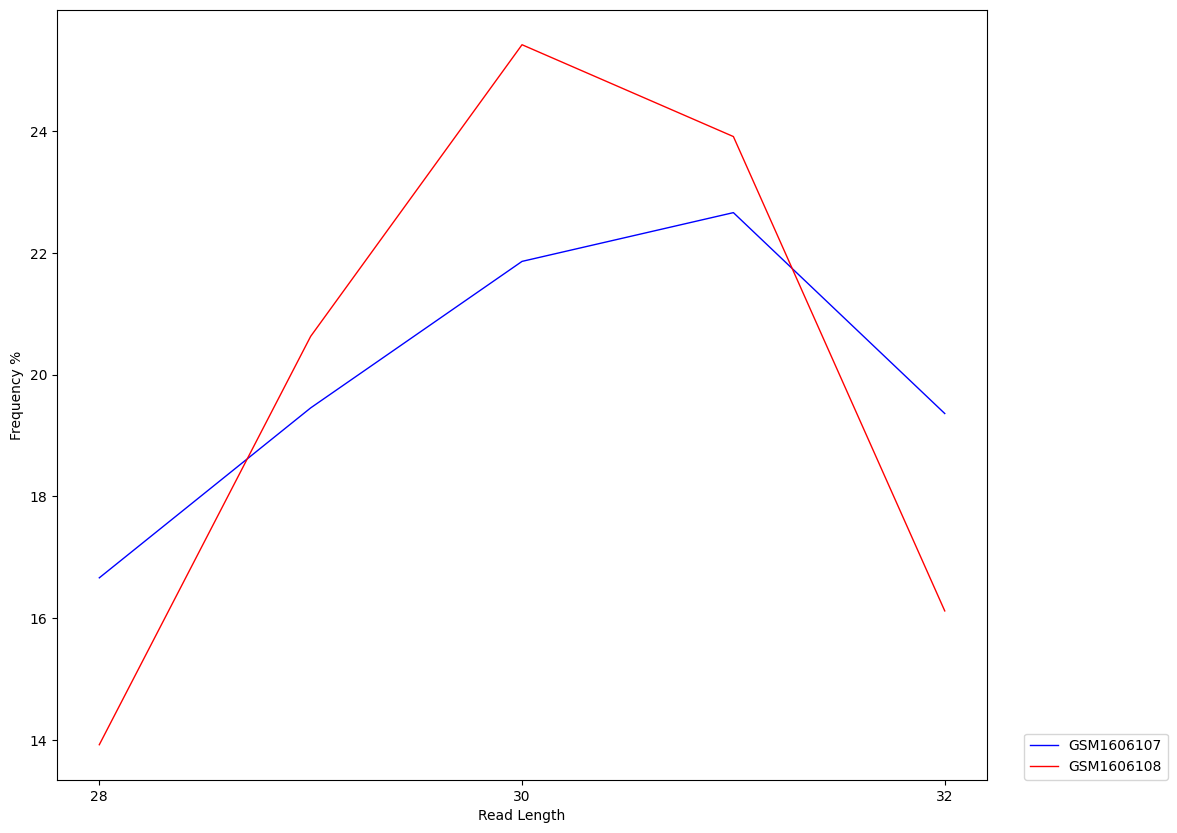

In [6]:
ribo_3.plot_lengthdist(region_type      = "CDS",
                            normalize   = True,
                            experiments = ["GSM1606107", "GSM1606108"])

In [7]:
length_dist_2 = ribo_2.get_length_dist(
                            region_name = "CDS",
                            experiments = ["GSM1606107", "GSM1606108"])

length_dist_3 = ribo_3.get_length_dist(
                            region_name = "CDS",
                            experiments = ["GSM1606107", "GSM1606108"])

In [8]:
length_dist_2.columns = ["GSM1606107", "GSM1606108"]
length_dist_3.columns = ["GSM1606107", "GSM1606108"]

#merged_length_dist = length_dist_2.merge(length_dist_3, how = "left", left_index = True)
merged_length_dist = length_dist_2.merge(length_dist_3, 
                                         left_index = True, right_index=True,
                                         suffixes   = ["_2", "_3"])
merged_length_dist

,GSM1606107_2,GSM1606108_2,GSM1606107_3,GSM1606108_3
read_length,,,,
28,594873,734536,591244,729929
29,694536,1088047,690319,1081774
30,780535,1340441,775738,1333040
31,809035,1261374,804168,1253919
32,691309,850455,687041,845215


## Metagene

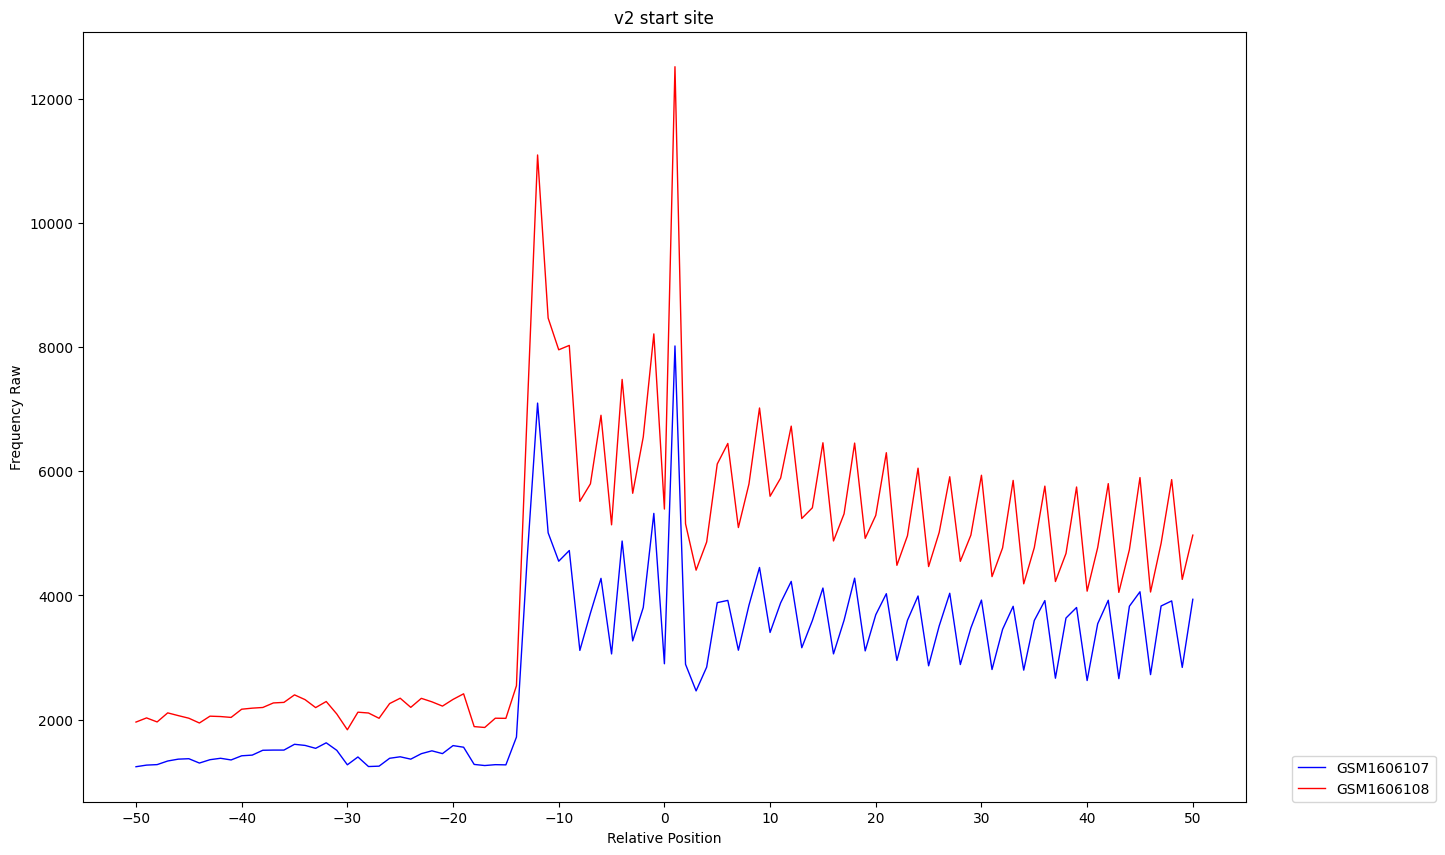

In [9]:
ribo_2.plot_metagene(site_type   = "start",
                          experiments = ["GSM1606107", "GSM1606108"],
                          range_lower = 28,
                          range_upper = 32,
                          title       = "v2 start site")

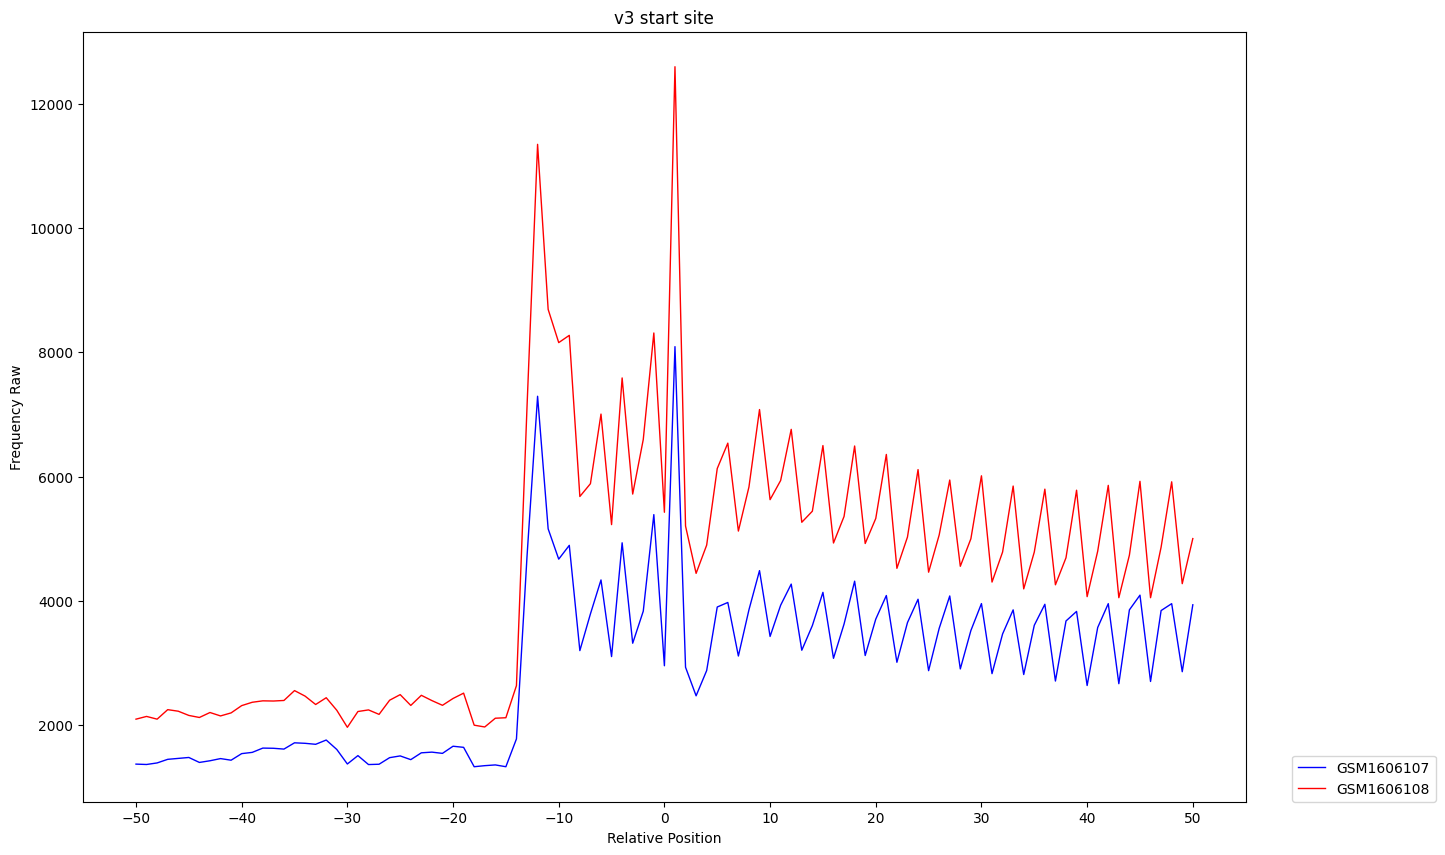

In [10]:
ribo_3.plot_metagene(site_type   = "start",
                          experiments = ["GSM1606107", "GSM1606108"],
                          range_lower = 28,
                          range_upper = 32,
                          title       = "v3 start site")

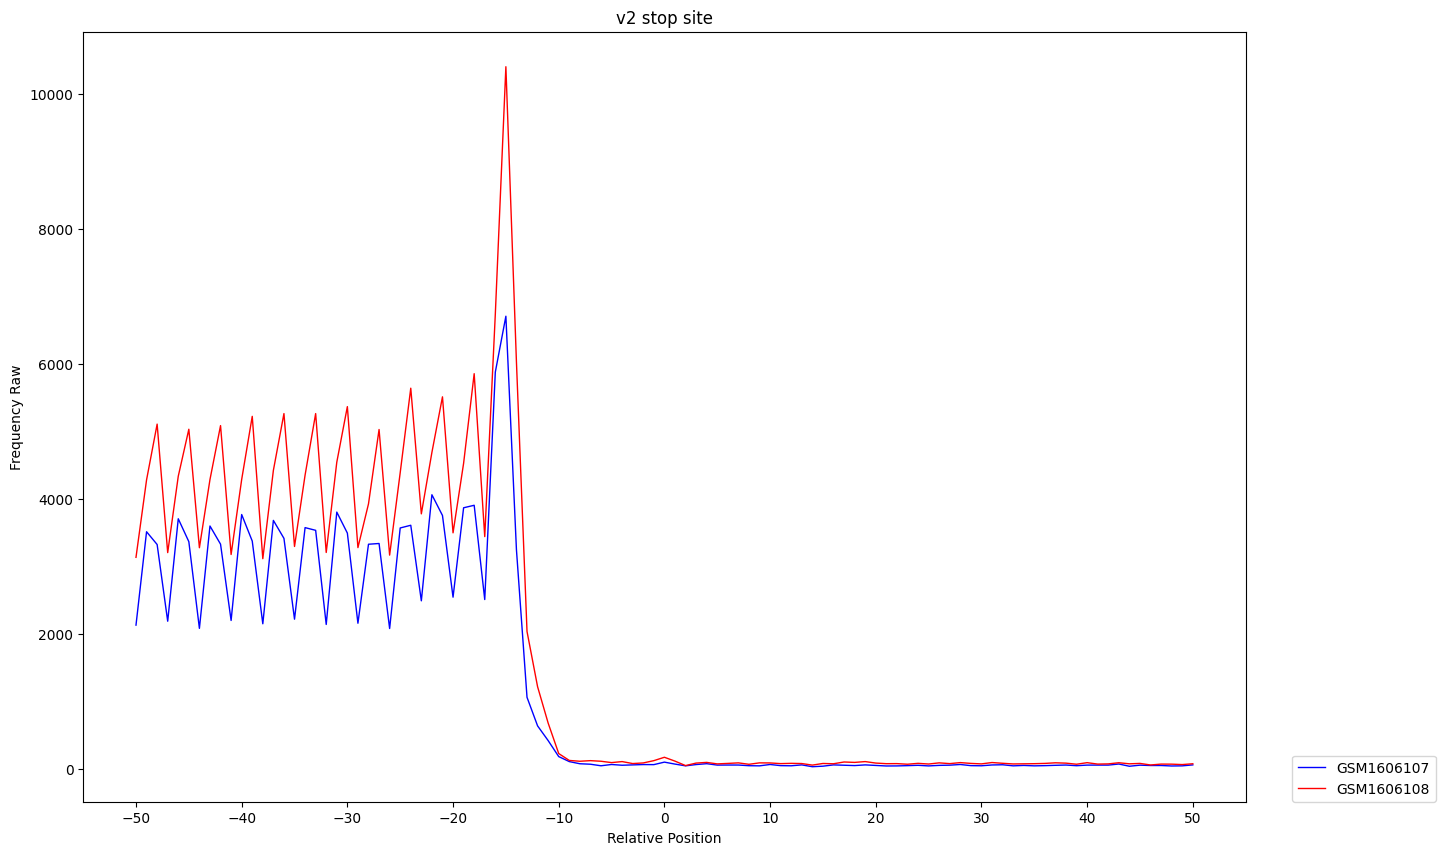

In [11]:
ribo_2.plot_metagene(site_type   = "stop",
                          experiments = ["GSM1606107", "GSM1606108"],
                          range_lower = 28,
                          range_upper = 32,
                          title       = "v2 stop site")

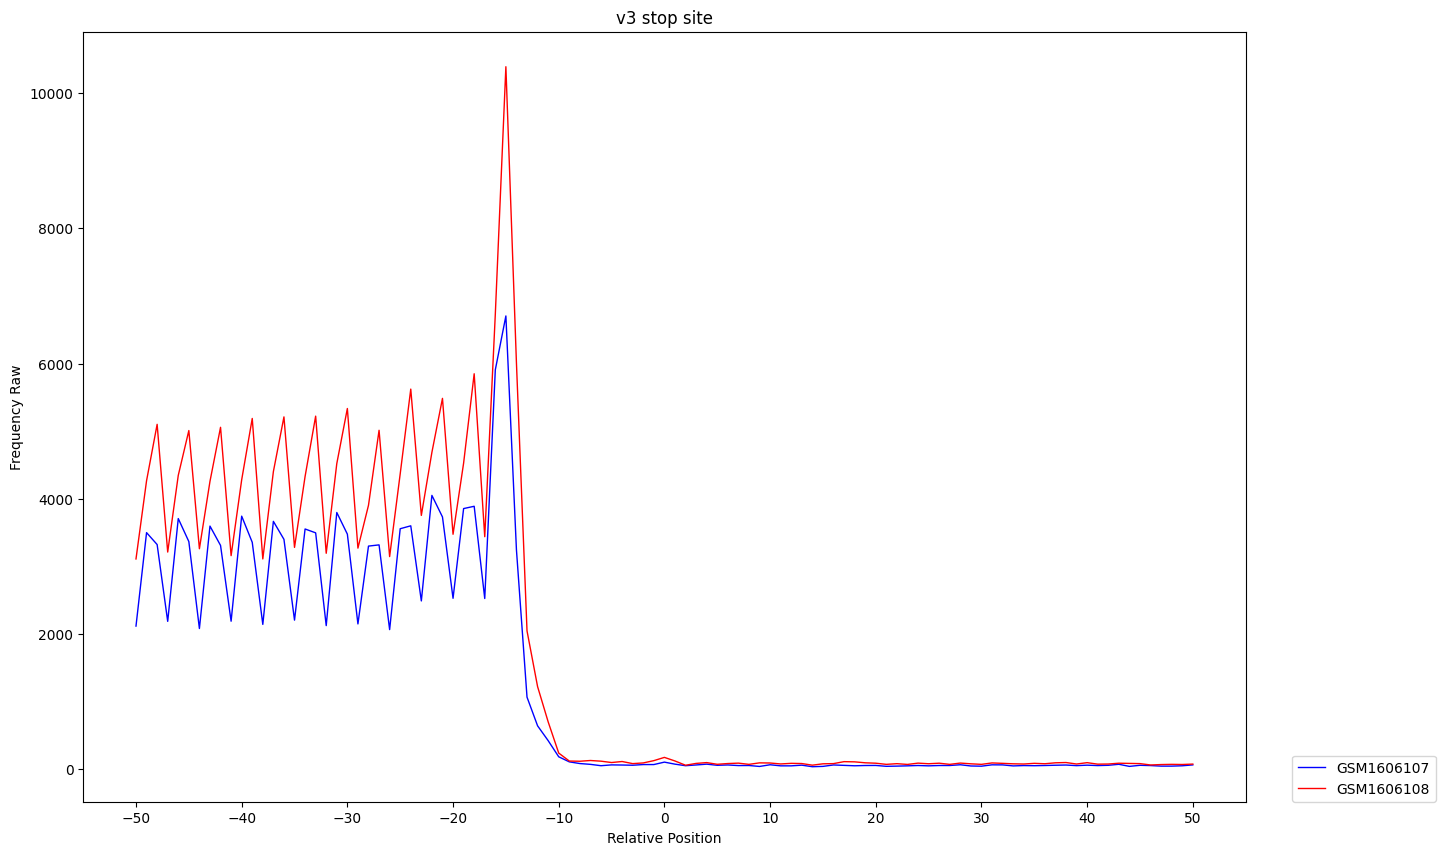

In [12]:
ribo_3.plot_metagene(site_type   = "stop",
                          experiments = ["GSM1606107", "GSM1606108"],
                          range_lower = 28,
                          range_upper = 32,
                          title       = "v3 stop site")

In [13]:
metagene_start_2 = \
   ribo_2.get_metagene(site_type      = "start",
                            range_lower    = 28,
                            range_upper    = 32,
                            sum_lengths    = True,
                            sum_references = True
                        ).astype("int64")

metagene_start_3 = \
   ribo_3.get_metagene(site_type      = "start",
                            range_lower    = 28,
                            range_upper    = 32,
                            sum_lengths    = True,
                            sum_references = True
                        ).astype("int64")

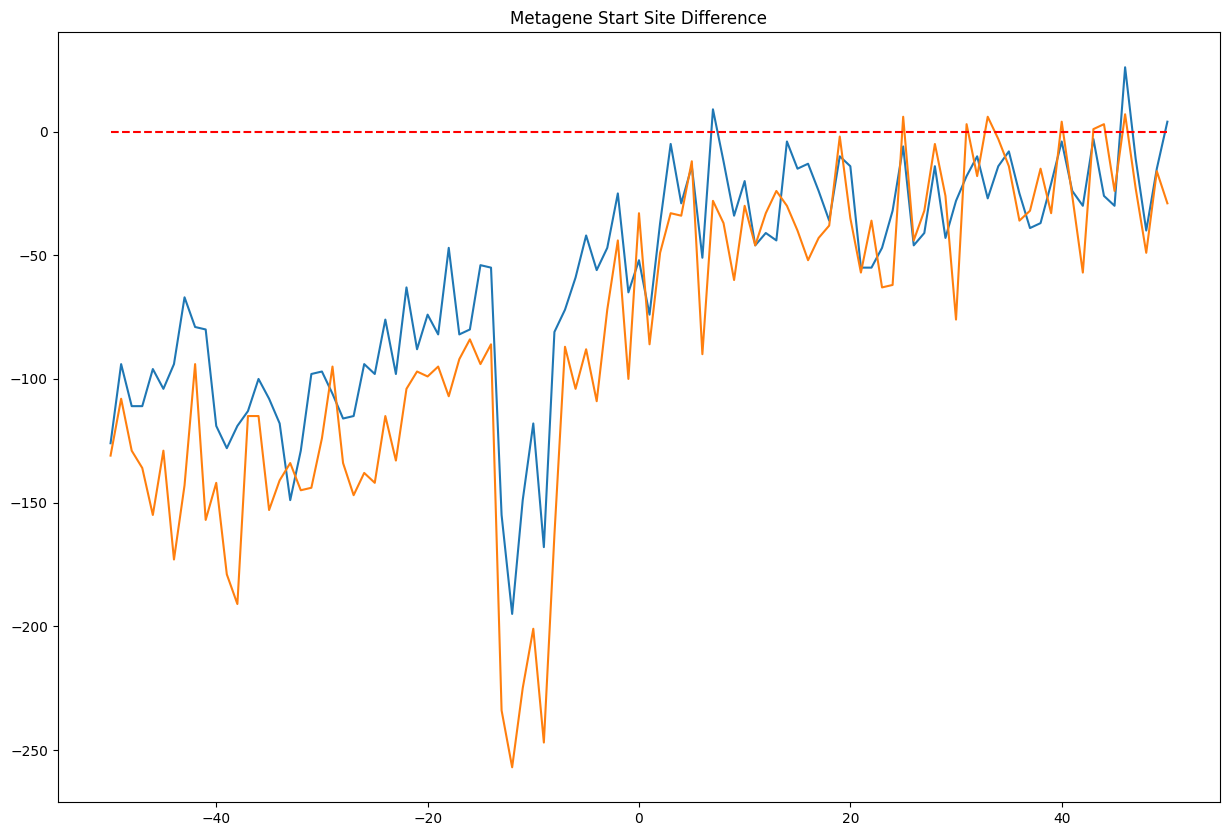

In [14]:

fig, ax = matplotlib.pyplot.subplots()
ax.plot((metagene_start_2 - metagene_start_3).loc["GSM1606107"])
ax.plot((metagene_start_2 - metagene_start_3).loc["GSM1606108"])
ax.hlines(y=0, xmin=-50, xmax = 50, color='r', linestyle='--');
plt.title("Metagene Start Site Difference");

In [15]:
metagene_stop_2 = \
   ribo_2.get_metagene(site_type      = "stop",
                            range_lower    = 28,
                            range_upper    = 32,
                            sum_lengths    = True,
                            sum_references = True
                        ).astype("int64")

metagene_stop_3 = \
   ribo_3.get_metagene(site_type      = "stop",
                            range_lower    = 28,
                            range_upper    = 32,
                            sum_lengths    = True,
                            sum_references = True
                        ).astype("int64")

stop_difference = metagene_stop_2 - metagene_stop_3

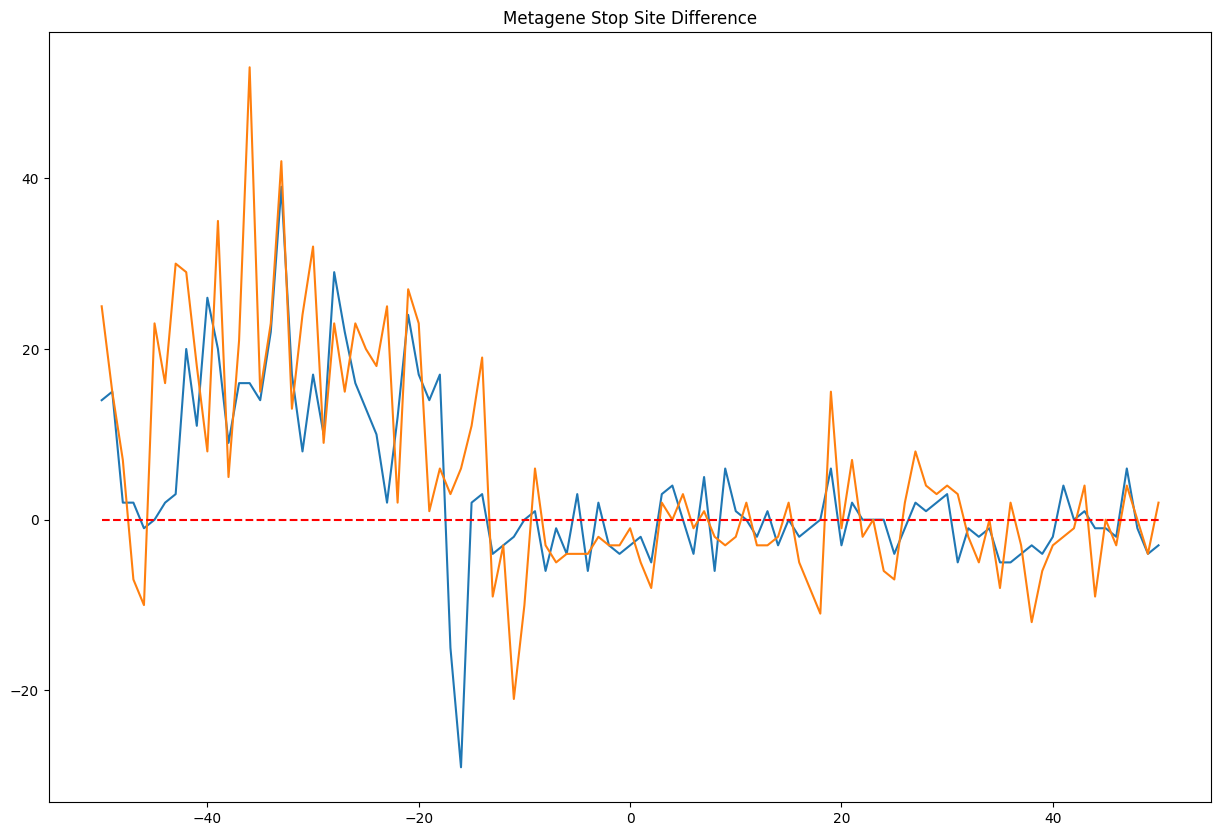

In [16]:
fig, ax = matplotlib.pyplot.subplots()
ax.plot((stop_difference).loc["GSM1606107"])
ax.plot((stop_difference).loc["GSM1606108"])
ax.hlines(y = 0, xmin = -50, xmax = 50, color = 'r', linestyle = '--');
plt.title("Metagene Stop Site Difference");

## Region Counts

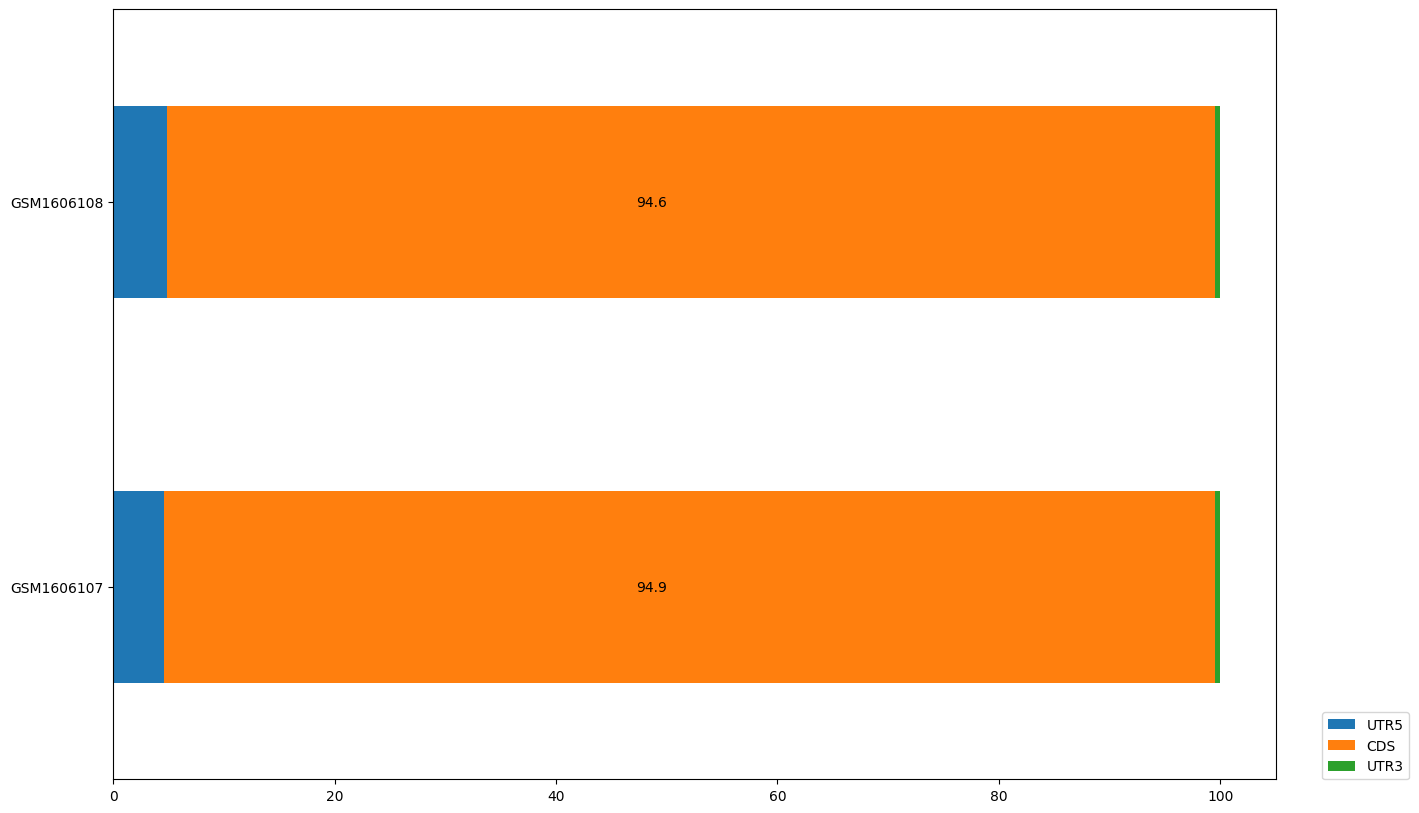

In [17]:
ribo_2.plot_region_counts(experiments = ["GSM1606107", "GSM1606108"],
                               range_lower = 28,
                               range_upper = 32,
                               horizontal  = True);

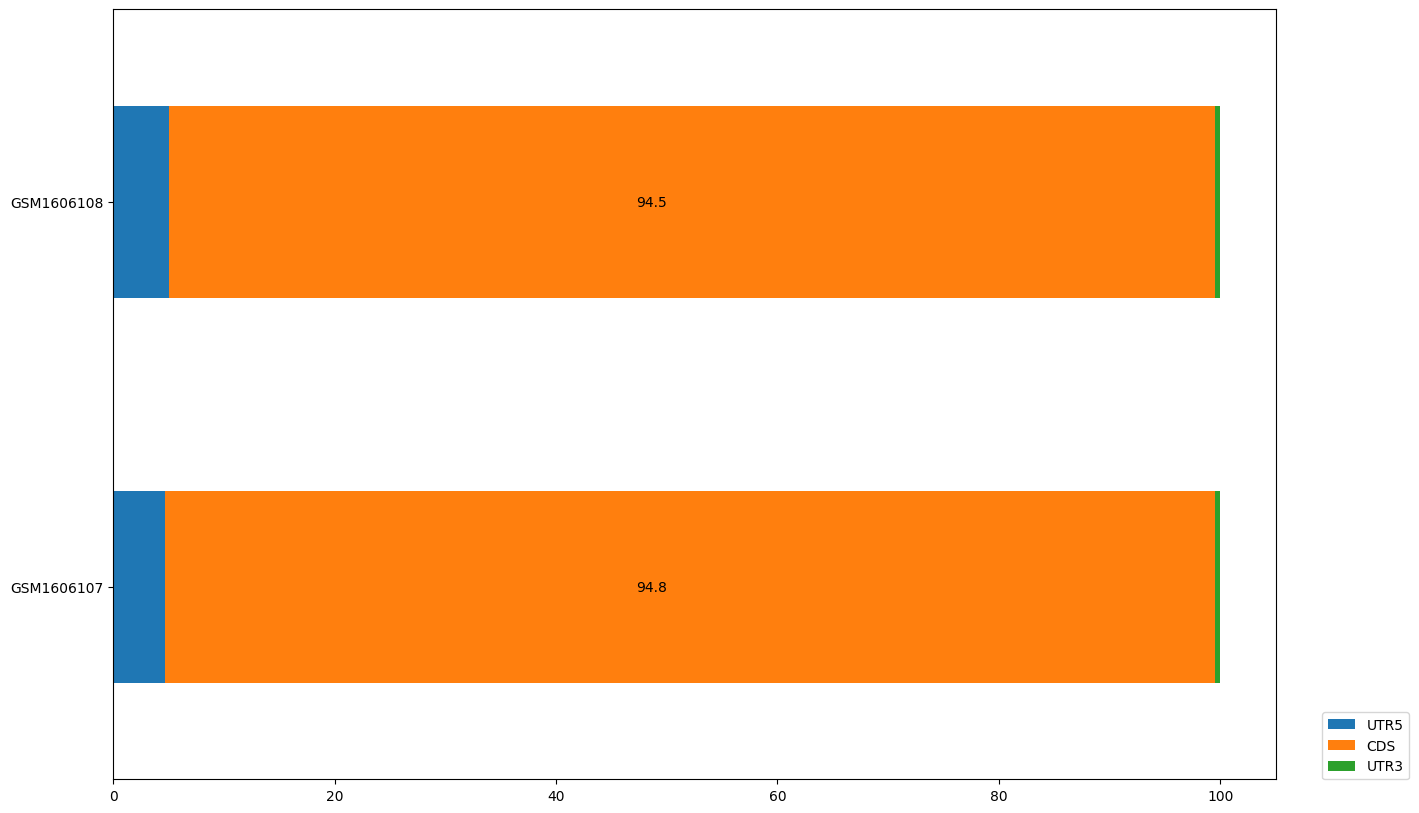

In [18]:
ribo_3.plot_region_counts(experiments = ["GSM1606107", "GSM1606108"],
                               range_lower = 28,
                               range_upper = 32,
                               horizontal  = True);

In [19]:
cds_2 = ribo_2.get_region_counts(experiments    = ["GSM1606107", "GSM1606108"],
                              region_name    = "CDS",
                              range_lower    = 28,
                              range_upper    = 32,
                              sum_lengths    = True,
                              alias          = True,
                              sum_references = False)

cds_3 = ribo_3.get_region_counts(experiments    = ["GSM1606107", "GSM1606108"],
                              region_name    = "CDS",
                              range_lower    = 28,
                              range_upper    = 32,
                              alias          = True,
                              sum_lengths    = True,
                              sum_references = False)

In [20]:
common_genes = sorted(set(cds_2.index).intersection(set(cds_3.index)))
cds_2_common = cds_2.loc[common_genes]["GSM1606107"]
cds_3_common = cds_3.loc[common_genes]["GSM1606107"]

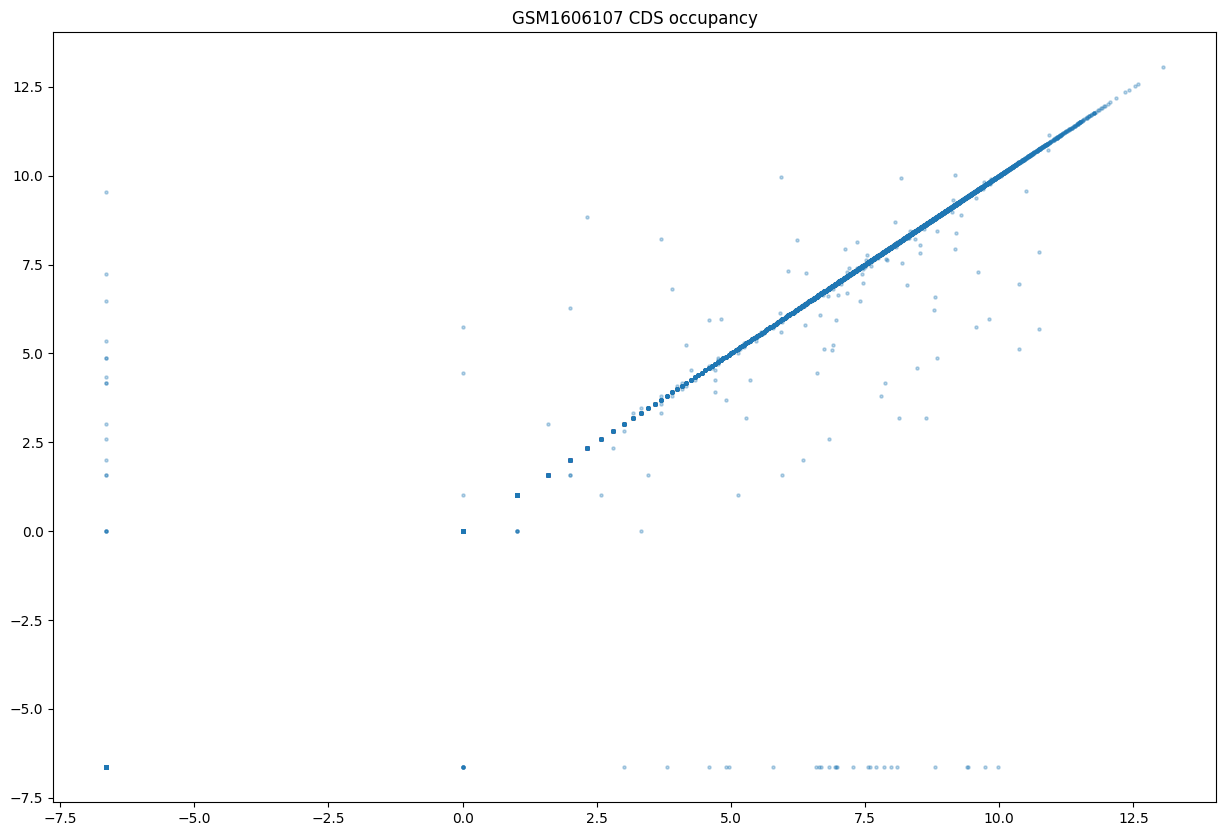

In [21]:
cds_2_log_counts = np.log2(np.array(cds_2_common) + 0.01)
cds_3_log_counts = np.log2(np.array(cds_3_common) + 0.01)

matplotlib.pyplot.scatter( cds_2_log_counts, cds_3_log_counts, alpha = 0.3, s = 5 );
plt.title("GSM1606107 CDS occupancy");

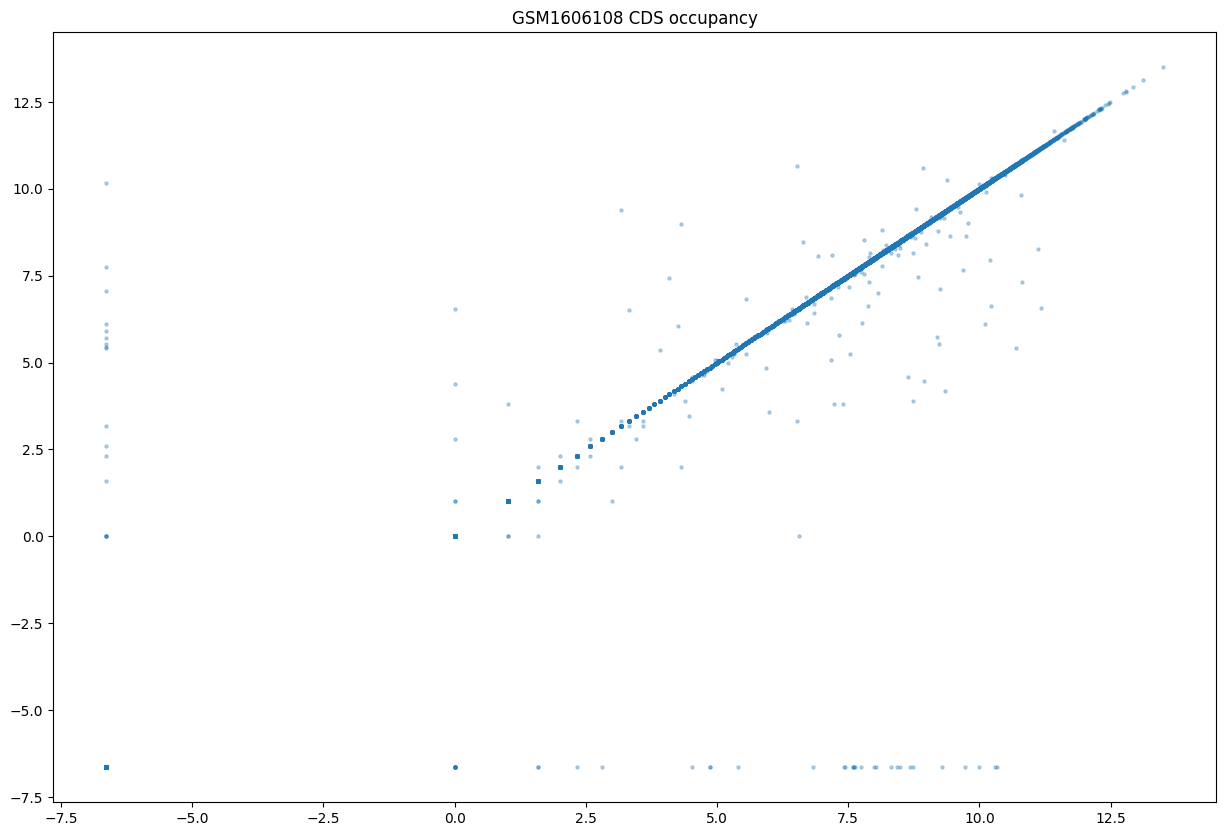

In [22]:
cds_2_common = cds_2.loc[common_genes]["GSM1606108"]
cds_3_common = cds_3.loc[common_genes]["GSM1606108"]

cds_2_log_counts = np.log2(np.array(cds_2_common) + 0.01)
cds_3_log_counts = np.log2(np.array(cds_3_common) + 0.01)

matplotlib.pyplot.scatter( cds_2_log_counts, cds_3_log_counts, alpha = 0.3, s = 5 );
plt.title("GSM1606108 CDS occupancy");

In [23]:
merged_cds = cds_2.merge(cds_3, 
                         left_index  = True, 
                         right_index = True,
                         suffixes    = ["_2", "_3"])

In [24]:
merged_cds["107_diff"] = pd.Series(merged_cds["GSM1606107_2"], dtype='int32') - \
                         pd.Series(merged_cds["GSM1606107_3"], dtype='int32')
merged_cds["108_diff"] = pd.Series(merged_cds["GSM1606108_2"], dtype='int32') - \
                         pd.Series(merged_cds["GSM1606108_3"], dtype='int32')
merged_cds["107_abs"]  = np.absolute(merged_cds["107_diff"])
merged_cds["108_abs"]  = np.absolute(merged_cds["108_diff"])

In [25]:
merged_cds.sort_values(by = ["107_abs"], ascending = False, inplace = True)
merged_cds

,GSM1606107_2,GSM1606108_2,GSM1606107_3,GSM1606108_3,107_diff,108_diff,107_abs,108_abs
transcript,,,,,,,,
SYNCRIP-202,1719,2314,51,95,1668,2219,1668,2219
RPSA-201,1719,2217,229,306,1490,1911,1490,1911
PPP2CA-203,1327,1667,35,43,1292,1624,1292,1624
IMPDH2-201,1316,1793,124,160,1192,1633,1192,1633
SKP1-202,1007,1265,0,0,1007,1265,1007,1265
...,...,...,...,...,...,...,...,...
FBXO9-202,219,304,219,304,0,0,0,0
GCM1-201,0,1,0,1,0,0,0,0
ELOVL5-201,692,1032,692,1032,0,0,0,0


In [26]:
merged_cds[ merged_cds["107_abs"] > 5 ]

,GSM1606107_2,GSM1606108_2,GSM1606107_3,GSM1606108_3,107_diff,108_diff,107_abs,108_abs
transcript,,,,,,,,
SYNCRIP-202,1719,2314,51,95,1668,2219,1668,2219
RPSA-201,1719,2217,229,306,1490,1911,1490,1911
PPP2CA-203,1327,1667,35,43,1292,1624,1292,1624
IMPDH2-201,1316,1793,124,160,1192,1633,1192,1633
SKP1-202,1007,1265,0,0,1007,1265,1007,1265
...,...,...,...,...,...,...,...,...
COG5-201,562,746,555,734,7,12,7,12
TOPORS-201,281,422,274,407,7,15,7,15
BCL2L2-PABPN1-203,0,1,6,7,-6,-6,6,6


In [27]:
merged_cds[ merged_cds["107_abs"] > 100 ]

,GSM1606107_2,GSM1606108_2,GSM1606107_3,GSM1606108_3,107_diff,108_diff,107_abs,108_abs
transcript,,,,,,,,
SYNCRIP-202,1719,2314,51,95,1668,2219,1668,2219
RPSA-201,1719,2217,229,306,1490,1911,1490,1911
PPP2CA-203,1327,1667,35,43,1292,1624,1292,1624
IMPDH2-201,1316,1793,124,160,1192,1633,1192,1633
SKP1-202,1007,1265,0,0,1007,1265,1007,1265
PWP2-201,61,92,992,1619,-931,-1527,931,1527
SLC25A6-201,849,1287,0,0,849,1287,849,1287
CYP51A1-201,901,1197,63,98,838,1099,838,1099
U2AF1-201,0,0,747,1149,-747,-1149,747,1149


In [28]:
for a in merged_cds[ merged_cds["107_abs"] > 50 ].index:
    print(a)

SYNCRIP-202
RPSA-201
PPP2CA-203
IMPDH2-201
SKP1-202
PWP2-201
SLC25A6-201
CYP51A1-201
U2AF1-201
QRICH1-202
TARDBP-201
HMGB1-203
SNRPD3-201
DCAF7-205
RHOA-202
RPS27A-201
SOD2-210
ITCH-202
SNX14-201
MRPS5-201
MEPCE-201
TACO1-201
IPO7-201
RBM8A-204
USP13-201
HAUS7-202
DYNLRB1-202
SLC5A3-201
VAMP7-202
TIMM23-201
CD99-205
PRRC2A-202
H2BC18-201
EXOSC4-201
IFRD1-202
STXBP2-201
GTPBP6-201
MND1-201
NDUFB5-201
PYURF-201
DIABLO-206
UBE2N-201
MAP2K2-201
GPAA1-201
AKAP17A-201
ASMTL-201
PLCXD1-201
MTAP-213
PSEN2-202
ARHGAP11A-201
ATP13A2-203
GSTT2B-201
COX8A-201
FAM174C-201
CHMP4B-201
MED20-201
ABHD16A-201
PPP2R3B-202
USP18-201
IPO11-201
DDT-202
EPDR1-201
NUDT3-201
PET100-202
PEX26-202
POLR2M-201
TIGAR-201
TXNL4B-201
CASTOR2-201
FAM120A-201
SRD5A3-201
SMIM13-202
DHRSX-201
PTPA-207
SIK1-201
PPP5C-201
